In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import torch

In [2]:
base = Path("../attributions")

save_base = Path("./figures")
save_base.mkdir(exist_ok=True)

enable_title = False
transparent = False


# Dreyer2023

In [3]:


def plot_temporal_saliency(dataset, model, window, subject=None, method="saliency", targets=[0, 1], ax=None, ylim=None, facecolor=(1,1,1,1)):
    if ax is None:
        fig, ax = plt.subplots()

    ax.set_facecolor(facecolor)

    files = os.listdir(base)
    files_to_load = []
    for file in files:
        if window in file and dataset in file and model in file:
            if subject is not None:
                if f"_{subject}.pt" in file:
                    files_to_load.append(file)
            else:
                files_to_load.append(file)

    saliency_list = []

    for file in files_to_load:
        data = torch.load(base / file, weights_only=False)
        for target in targets:
            saliency = data[target][method]
            saliency_list.append(saliency)

    saliency_all = np.array(saliency_list)

    saliency_temporal = saliency_all.mean(1)

    saliency_temporal = saliency_temporal / saliency_temporal.sum(1)[:, None] * 100

    t1 = window.split("_")[1]
    t2 = window.split("_")[2]

    t1 = float(f"{t1[0]}.{t1[1]}")
    t2 = float(f"{t2[0]}.{t2[1]}")

    times = np.linspace(t1, t2, saliency_temporal.shape[1])

    saliency_mean = saliency_temporal.mean(0)
    saliency_std = saliency_temporal.std(0)

    ax.plot(times, saliency_mean, color = "black")
    ax.fill_between(
    times,
    saliency_mean - saliency_std,
    saliency_mean + saliency_std,
    color="gray"
)
    ax.set_xlabel("Time [samples]")
    ax.set_ylabel("Saliency in %")

    if ylim is not None:
        ax.set_ylim(ylim)


def plot_spatial_saliency(dataset, model, window, subject=None, method="saliency", targets=[0, 1],
                          montage="standard_1005", ax=None, ylim=None):
    if ax is None:
        fig, ax = plt.subplots()

    with open(f"../Dataset/{dataset}/meta_data.json", "r") as f:
        info = json.load(f)
    ch_names = info["ch_names"]

    files = os.listdir(base)
    files_to_load = []
    for file in files:
        if window in file and dataset in file and model in file:
            if subject is not None:
                if f"_{subject}.pt" in file:
                    files_to_load.append(file)
            else:
                files_to_load.append(file)

    saliency_list = []

    for file in files_to_load:
        data = torch.load(base / file, weights_only=False)
        for target in targets:
            saliency = data[target][method]
            saliency_list.append(saliency)

    saliency_all = np.array(saliency_list)

    saliency_spatial = saliency_all.mean(2)
    saliency_spatial = saliency_spatial / saliency_spatial.sum(1)[:, None] * 100

    info = mne.create_info(ch_names, 1000.0, "eeg")
    info.set_montage(montage)

    montage = mne.channels.make_standard_montage(montage)
    ch_pos = montage.get_positions()["ch_pos"]
    ch_pos = np.array([ch_pos[ch_name][:2] for ch_name in ch_names])

    if ylim is not None:
        im, _ = mne.viz.plot_topomap(saliency_spatial.mean(0), ch_pos, names=ch_names, cmap="Reds", axes=ax, show=False,
                                     vlim=ylim)
    else:
        im, _ = mne.viz.plot_topomap(saliency_spatial.mean(0), ch_pos, names=ch_names, cmap="Reds", axes=ax, show=False)

    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label("Saliency in %", rotation=270, labelpad=30)


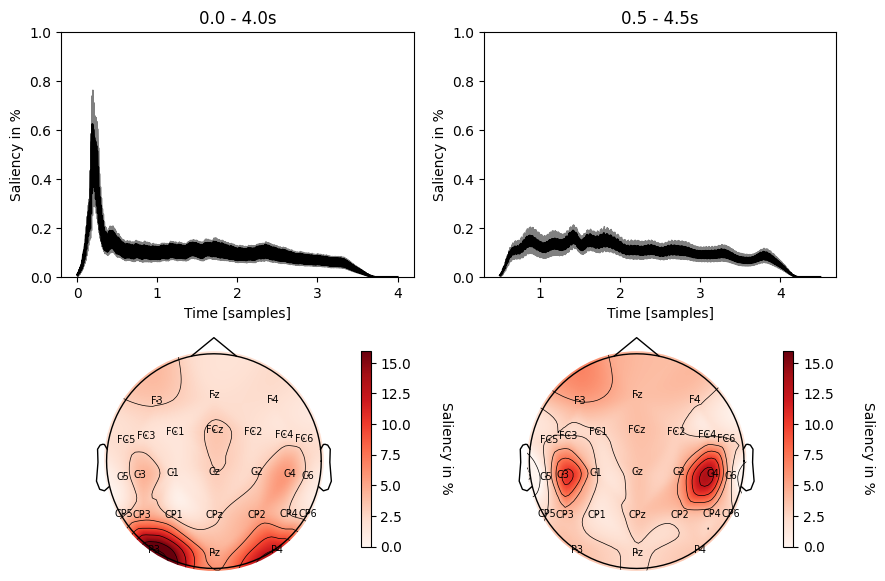

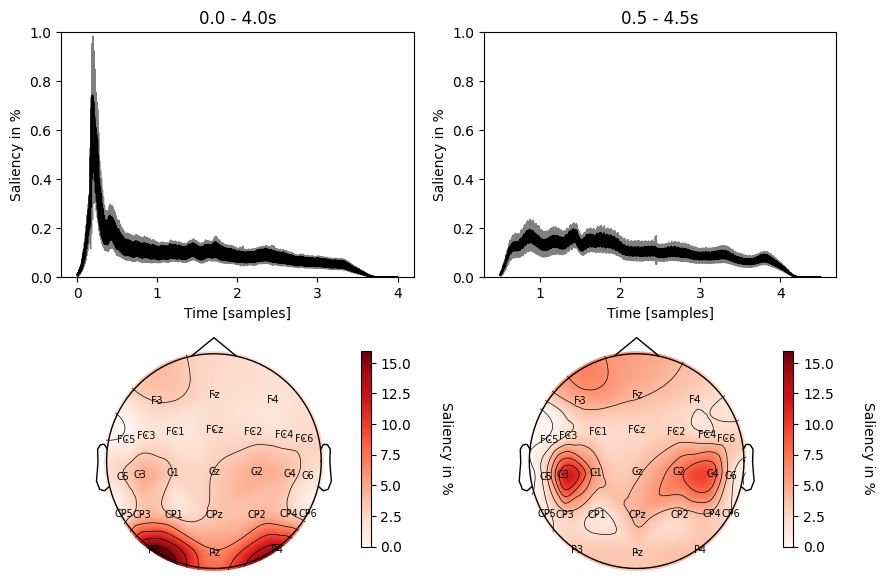

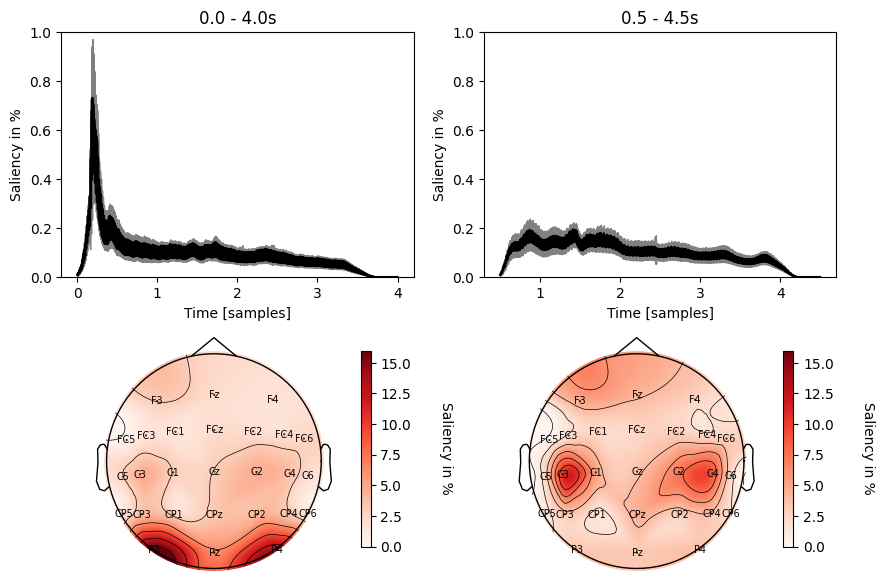

In [4]:

dataset = "Dreyer2023"
model = "Deep4Net"
model_name = "DeepConvNet"
windows = ["w_00_40", "w_05_45"]
#ylim_temporal = None
ylim_temporal = [0, 1.0]
ylim_spatial = [0, 16]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

plot_temporal_saliency(dataset, model, windows[0], subject=None, method="saliency", targets=[0, 1], ax=axes[0, 0],
                       ylim=ylim_temporal)
plot_temporal_saliency(dataset, model, windows[1], subject=None, method="saliency", targets=[0, 1], ax=axes[0, 1],
                       ylim=ylim_temporal)

plot_spatial_saliency(dataset, model, windows[0], subject=None, method="saliency", targets=[0, 1], ax=axes[1, 0],
                      ylim=ylim_spatial)
plot_spatial_saliency(dataset, model, windows[1], subject=None, method="saliency", targets=[0, 1], ax=axes[1, 1],
                      ylim=ylim_spatial)

axes[0, 0].set_title("0.0 - 4.0s")
axes[0, 1].set_title("0.5 - 4.5s")
if enable_title:
    fig.suptitle(f"{dataset} {model_name} (Saliency)")
fig.savefig(save_base / "Dreyer2023_DeepConvNet_Saliency.png", dpi=300, transparent=transparent)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
plot_temporal_saliency(dataset, model, windows[0], subject=None, method="integrated_gradients", targets=[0, 1],
                       ax=axes[0, 0], ylim=ylim_temporal)
plot_temporal_saliency(dataset, model, windows[1], subject=None, method="integrated_gradients", targets=[0, 1],
                       ax=axes[0, 1], ylim=ylim_temporal)

plot_spatial_saliency(dataset, model, windows[0], subject=None, method="integrated_gradients", targets=[0, 1],
                      ax=axes[1, 0], ylim=ylim_spatial)
plot_spatial_saliency(dataset, model, windows[1], subject=None, method="integrated_gradients", targets=[0, 1],
                      ax=axes[1, 1], ylim=ylim_spatial)

axes[0, 0].set_title("0.0 - 4.0s")
axes[0, 1].set_title("0.5 - 4.5s")
if enable_title:
    fig.suptitle(f"{dataset} {model_name} (Integrated Gradients)")
fig.savefig(save_base / "Dreyer2023_DeepConvNet_IG.png", dpi=300, transparent=transparent)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
plot_temporal_saliency(dataset, model, windows[0], subject=None, method="deeplift", targets=[0, 1],
                       ax=axes[0, 0], ylim=ylim_temporal)
plot_temporal_saliency(dataset, model, windows[1], subject=None, method="deeplift", targets=[0, 1],
                       ax=axes[0, 1], ylim=ylim_temporal)

plot_spatial_saliency(dataset, model, windows[0], subject=None, method="deeplift", targets=[0, 1],
                      ax=axes[1, 0], ylim=ylim_spatial)
plot_spatial_saliency(dataset, model, windows[1], subject=None, method="deeplift", targets=[0, 1],
                      ax=axes[1, 1], ylim=ylim_spatial)

axes[0, 0].set_title("0.0 - 4.0s")
axes[0, 1].set_title("0.5 - 4.5s")
if enable_title:
    fig.suptitle(f"{dataset} {model_name} (DeepLIFT)")
fig.savefig(save_base / "Dreyer2023_DeepConvNet_DeepLIFT.png", dpi=300, transparent=transparent)



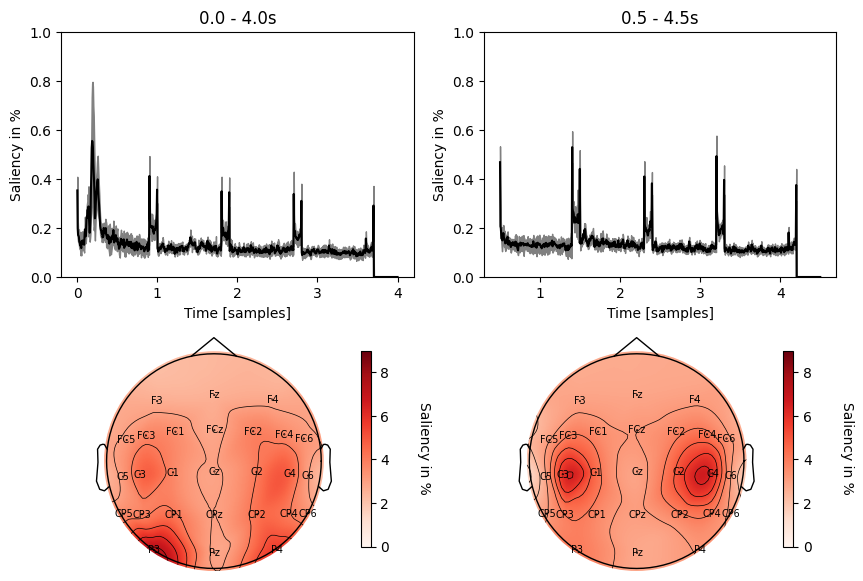

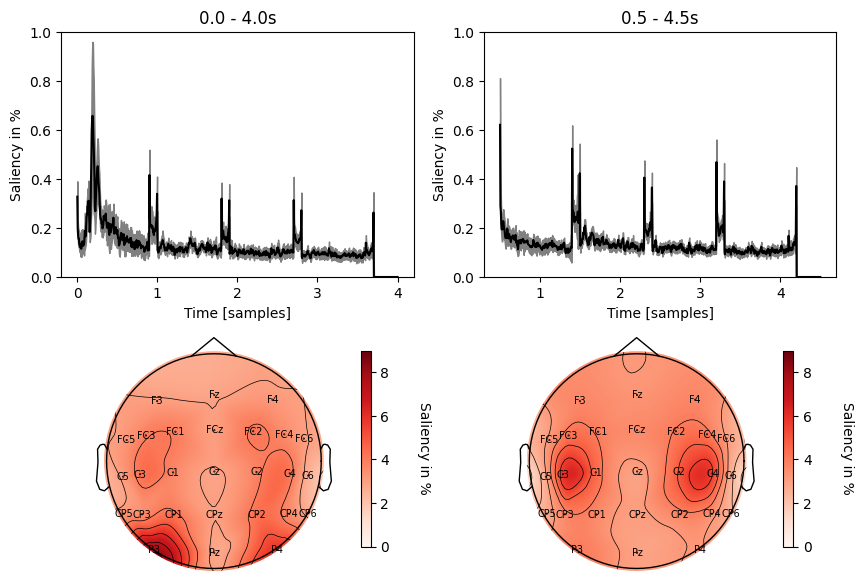

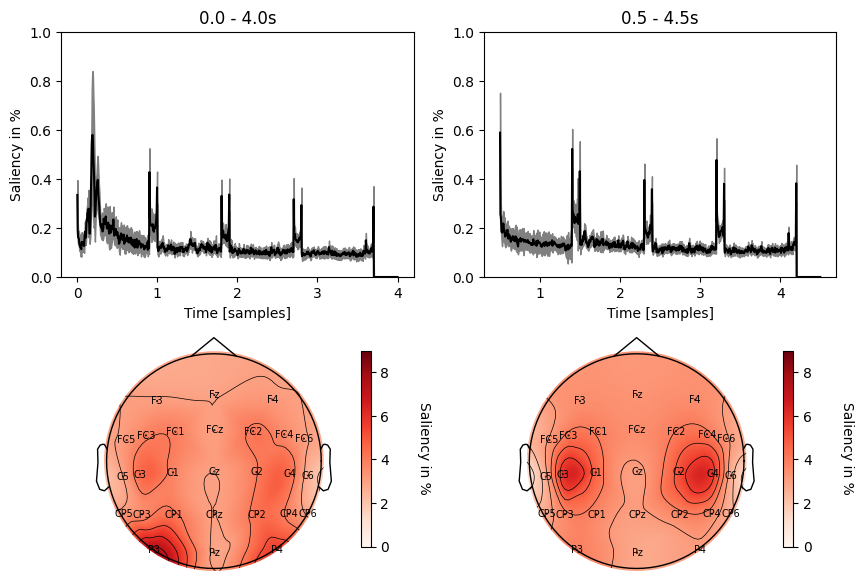

In [5]:

dataset = "Dreyer2023"
model = "REVE"
model_name = "REVE"
windows = ["w_00_40", "w_05_45"]
ylim_temporal = [0, 1.0]
#ylim_temporal = None
ylim_spatial = [0, 9]
#ylim_spatial = None

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

plot_temporal_saliency(dataset, model, windows[0], subject=None, method="saliency", targets=[0, 1], ax=axes[0, 0],
                       ylim=ylim_temporal)
plot_temporal_saliency(dataset, model, windows[1], subject=None, method="saliency", targets=[0, 1], ax=axes[0, 1],
                       ylim=ylim_temporal)

plot_spatial_saliency(dataset, model, windows[0], subject=None, method="saliency", targets=[0, 1], ax=axes[1, 0],
                      ylim=ylim_spatial)
plot_spatial_saliency(dataset, model, windows[1], subject=None, method="saliency", targets=[0, 1], ax=axes[1, 1],
                      ylim=ylim_spatial)

axes[0, 0].set_title("0.0 - 4.0s")
axes[0, 1].set_title("0.5 - 4.5s")
if enable_title:
    fig.suptitle(f"{dataset} {model_name} (Saliency)")
fig.savefig(save_base / "Dreyer2023_REVE_Saliency.png", dpi=300, transparent=transparent)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
plot_temporal_saliency(dataset, model, windows[0], subject=None, method="integrated_gradients", targets=[0, 1],
                       ax=axes[0, 0], ylim=ylim_temporal)
plot_temporal_saliency(dataset, model, windows[1], subject=None, method="integrated_gradients", targets=[0, 1],
                       ax=axes[0, 1], ylim=ylim_temporal)

plot_spatial_saliency(dataset, model, windows[0], subject=None, method="integrated_gradients", targets=[0, 1],
                      ax=axes[1, 0], ylim=ylim_spatial)
plot_spatial_saliency(dataset, model, windows[1], subject=None, method="integrated_gradients", targets=[0, 1],
                      ax=axes[1, 1], ylim=ylim_spatial)

axes[0, 0].set_title("0.0 - 4.0s")
axes[0, 1].set_title("0.5 - 4.5s")
if enable_title:
    fig.suptitle(f"{dataset} {model_name} (Integrated Gradients)")
fig.savefig(save_base / "Dreyer2023_REVE_IG.png", dpi=300, transparent=transparent)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
plot_temporal_saliency(dataset, model, windows[0], subject=None, method="deeplift", targets=[0, 1],
                       ax=axes[0, 0], ylim=ylim_temporal)
plot_temporal_saliency(dataset, model, windows[1], subject=None, method="deeplift", targets=[0, 1],
                       ax=axes[0, 1], ylim=ylim_temporal)

plot_spatial_saliency(dataset, model, windows[0], subject=None, method="deeplift", targets=[0, 1],
                      ax=axes[1, 0], ylim=ylim_spatial)
plot_spatial_saliency(dataset, model, windows[1], subject=None, method="deeplift", targets=[0, 1],
                      ax=axes[1, 1], ylim=ylim_spatial)

axes[0, 0].set_title("0.0 - 4.0s")
axes[0, 1].set_title("0.5 - 4.5s")
if enable_title:
    fig.suptitle(f"{dataset} {model_name} (DeepLIFT)")
fig.savefig(save_base / "Dreyer2023_REVE_DeepLIFT.png", dpi=300, transparent=transparent)



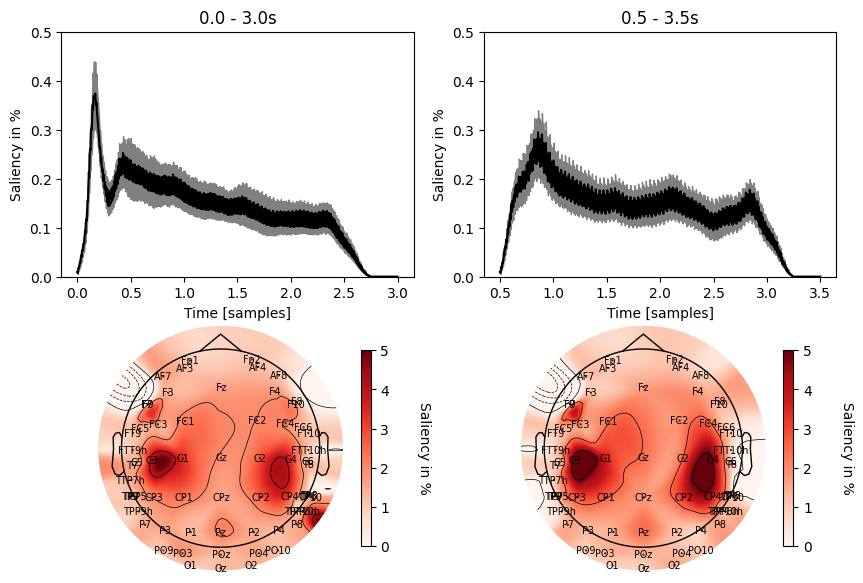

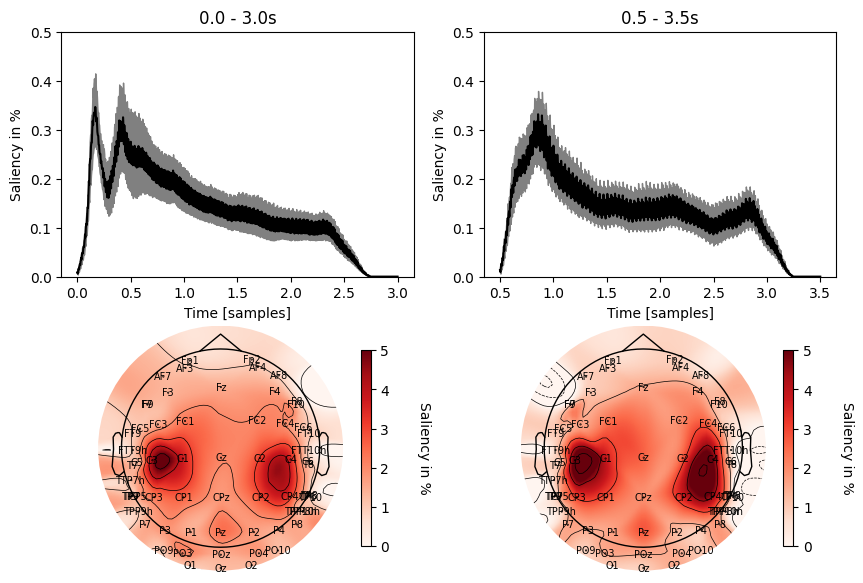

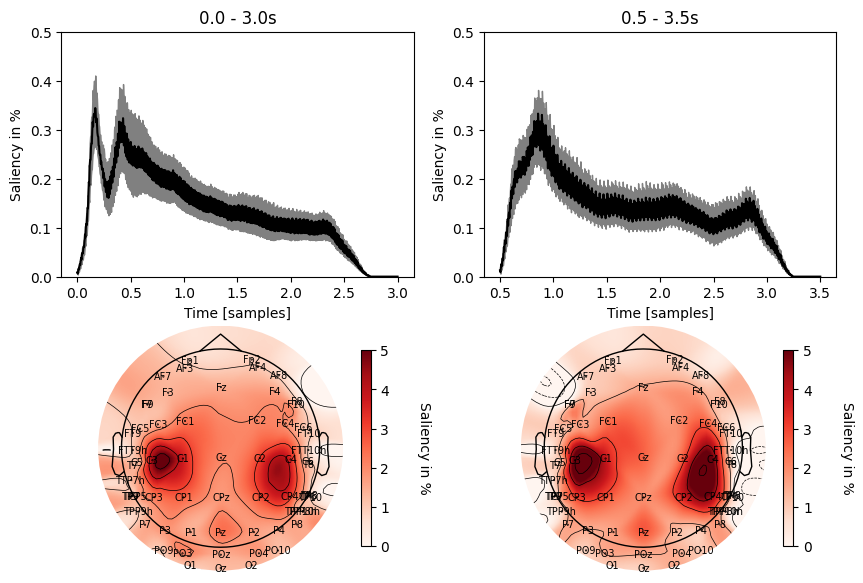

In [6]:

dataset = "Lee2019_MI"
model = "Deep4Net"
model_name = "DeepConvNet"
windows = ["w_00_30", "w_05_35"]
#ylim_temporal = None
ylim_temporal = [0, 0.5]
#ylim_spatial = None
ylim_spatial = [0, 5]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

plot_temporal_saliency(dataset, model, windows[0], subject=None, method="saliency", targets=[0, 1], ax=axes[0, 0],
                       ylim=ylim_temporal)
plot_temporal_saliency(dataset, model, windows[1], subject=None, method="saliency", targets=[0, 1], ax=axes[0, 1],
                       ylim=ylim_temporal)

plot_spatial_saliency(dataset, model, windows[0], subject=None, method="saliency", targets=[0, 1], ax=axes[1, 0],
                      ylim=ylim_spatial)
plot_spatial_saliency(dataset, model, windows[1], subject=None, method="saliency", targets=[0, 1], ax=axes[1, 1],
                      ylim=ylim_spatial)

axes[0, 0].set_title("0.0 - 3.0s")
axes[0, 1].set_title("0.5 - 3.5s")
if enable_title:
    fig.suptitle(f"{dataset} {model_name} (Saliency)")
fig.savefig(save_base / "Lee2019_MI_DeepConvNet_Saliency.png", dpi=300, transparent=transparent)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
plot_temporal_saliency(dataset, model, windows[0], subject=None, method="integrated_gradients", targets=[0, 1],
                       ax=axes[0, 0], ylim=ylim_temporal)
plot_temporal_saliency(dataset, model, windows[1], subject=None, method="integrated_gradients", targets=[0, 1],
                       ax=axes[0, 1], ylim=ylim_temporal)

plot_spatial_saliency(dataset, model, windows[0], subject=None, method="integrated_gradients", targets=[0, 1],
                      ax=axes[1, 0], ylim=ylim_spatial)
plot_spatial_saliency(dataset, model, windows[1], subject=None, method="integrated_gradients", targets=[0, 1],
                      ax=axes[1, 1], ylim=ylim_spatial)

axes[0, 0].set_title("0.0 - 3.0s")
axes[0, 1].set_title("0.5 - 3.5s")
if enable_title:
    fig.suptitle(f"{dataset} {model_name} (Integrated Gradients)")
fig.savefig(save_base / "Lee2019_MI_DeepConvNet_IG.png", dpi=300, transparent=transparent)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
plot_temporal_saliency(dataset, model, windows[0], subject=None, method="deeplift", targets=[0, 1],
                       ax=axes[0, 0], ylim=ylim_temporal)
plot_temporal_saliency(dataset, model, windows[1], subject=None, method="deeplift", targets=[0, 1],
                       ax=axes[0, 1], ylim=ylim_temporal)

plot_spatial_saliency(dataset, model, windows[0], subject=None, method="deeplift", targets=[0, 1],
                      ax=axes[1, 0], ylim=ylim_spatial)
plot_spatial_saliency(dataset, model, windows[1], subject=None, method="deeplift", targets=[0, 1],
                      ax=axes[1, 1], ylim=ylim_spatial)

axes[0, 0].set_title("0.0 - 3.0s")
axes[0, 1].set_title("0.5 - 3.5s")
if enable_title:
    fig.suptitle(f"{dataset} {model_name} (DeepLIFT)")
fig.savefig(save_base / "Lee2019_MI_DeepConvNet_DeepLIFT.png", dpi=300, transparent=transparent)



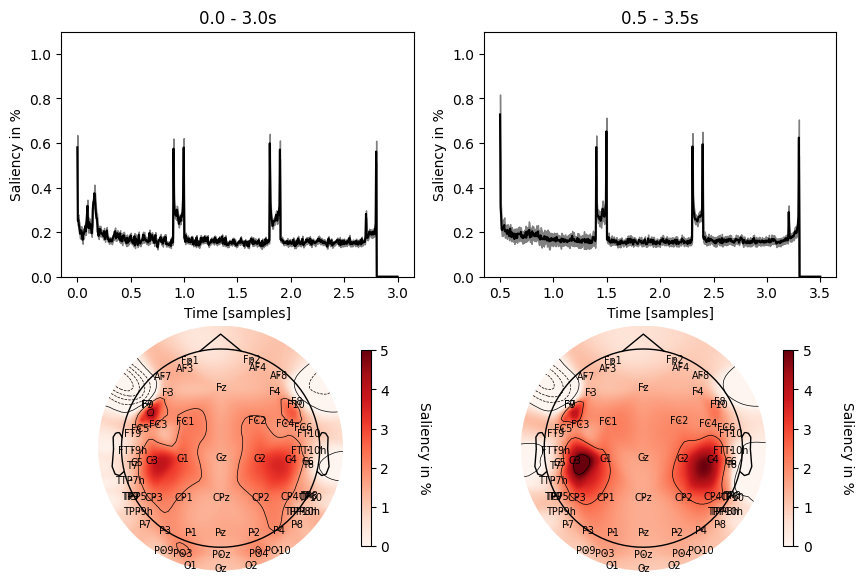

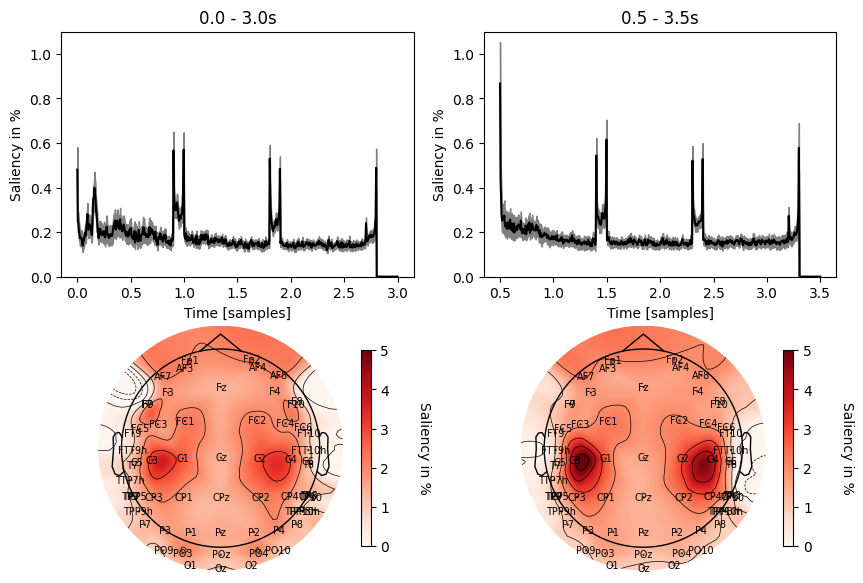

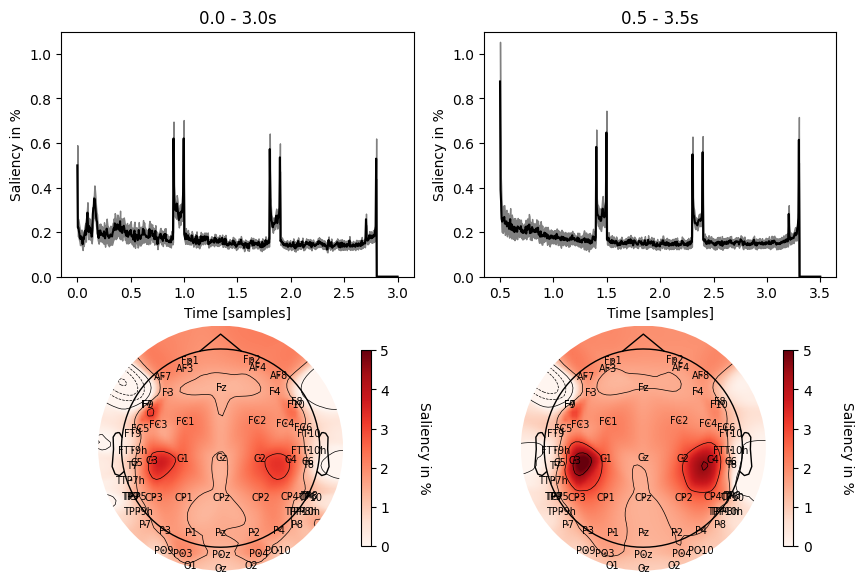

In [7]:
dataset = "Lee2019_MI"
model = "REVE"
model_name = "REVE"
windows = ["w_00_30", "w_05_35"]
ylim_temporal = [0, 1.1]
#ylim_temporal = None
ylim_spatial = [0, 5]
#ylim_spatial = None

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

plot_temporal_saliency(dataset, model, windows[0], subject=None, method="saliency", targets=[0, 1], ax=axes[0, 0],
                       ylim=ylim_temporal)
plot_temporal_saliency(dataset, model, windows[1], subject=None, method="saliency", targets=[0, 1], ax=axes[0, 1],
                       ylim=ylim_temporal)

plot_spatial_saliency(dataset, model, windows[0], subject=None, method="saliency", targets=[0, 1], ax=axes[1, 0],
                      ylim=ylim_spatial)
plot_spatial_saliency(dataset, model, windows[1], subject=None, method="saliency", targets=[0, 1], ax=axes[1, 1],
                      ylim=ylim_spatial)

axes[0, 0].set_title("0.0 - 3.0s")
axes[0, 1].set_title("0.5 - 3.5s")
if enable_title:
    fig.suptitle(f"{dataset} {model_name} (Saliency)")
fig.savefig(save_base / "Lee2019_MI_REVE_Saliency.png", dpi=300, transparent=transparent)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
plot_temporal_saliency(dataset, model, windows[0], subject=None, method="integrated_gradients", targets=[0, 1],
                       ax=axes[0, 0], ylim=ylim_temporal)
plot_temporal_saliency(dataset, model, windows[1], subject=None, method="integrated_gradients", targets=[0, 1],
                       ax=axes[0, 1], ylim=ylim_temporal)

plot_spatial_saliency(dataset, model, windows[0], subject=None, method="integrated_gradients", targets=[0, 1],
                      ax=axes[1, 0], ylim=ylim_spatial)
plot_spatial_saliency(dataset, model, windows[1], subject=None, method="integrated_gradients", targets=[0, 1],
                      ax=axes[1, 1], ylim=ylim_spatial)

axes[0, 0].set_title("0.0 - 3.0s")
axes[0, 1].set_title("0.5 - 3.5s")
if enable_title:
    fig.suptitle(f"{dataset} {model_name} (Integrated Gradients)")
fig.savefig(save_base / "Lee2019_MI_REVE_IG.png", dpi=300, transparent=transparent)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
plot_temporal_saliency(dataset, model, windows[0], subject=None, method="deeplift", targets=[0, 1],
                       ax=axes[0, 0], ylim=ylim_temporal)
plot_temporal_saliency(dataset, model, windows[1], subject=None, method="deeplift", targets=[0, 1],
                       ax=axes[0, 1], ylim=ylim_temporal)

plot_spatial_saliency(dataset, model, windows[0], subject=None, method="deeplift", targets=[0, 1],
                      ax=axes[1, 0], ylim=ylim_spatial)
plot_spatial_saliency(dataset, model, windows[1], subject=None, method="deeplift", targets=[0, 1],
                      ax=axes[1, 1], ylim=ylim_spatial)

axes[0, 0].set_title("0.0 - 3.0s")
axes[0, 1].set_title("0.5 - 3.5s")
if enable_title:
    fig.suptitle(f"{dataset} {model_name} (DeepLIFT)")
fig.savefig(save_base / "Lee2019_MI_REVE_DeepLIFT.png", dpi=300, transparent=transparent)
